## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Skripsi_Faris'
print("Google Drive berhasil di-mount. Folder:", DRIVE_PATH)

Mounted at /content/drive
Google Drive berhasil di-mount. Folder: /content/drive/MyDrive/Skripsi_Faris


## 1. Load Dataset Hasil Preprocessing

In [2]:
import pandas as pd

STEMMING_PATH = f'{DRIVE_PATH}/7_stemming_data.csv'
data_clean = pd.read_csv(STEMMING_PATH)

print("=== HASIL LOAD DATASET ===")
print(f"Jumlah data  : {len(data_clean)}")
print(f"Kolom        : {list(data_clean.columns)}")
print()
print("Distribusi label:")
print(data_clean['Label'].value_counts())
print()
data_clean[['content', 'text_stemindo', 'Label']].head(10)

=== HASIL LOAD DATASET ===
Jumlah data  : 8364
Kolom        : ['content', 'score', 'Label', 'text_clean', 'text_StopWord', 'text_tokens', 'text_stemindo']

Distribusi label:
Label
Positif    3891
Netral     3803
Negatif     670
Name: count, dtype: int64



,content,text_stemindo,Label
0,top,top,Positif
1,sangat membantu mengubah poto jadi bagus saya ...,bantu ubah poto bagus senang,Positif
2,maksa bet dari pertama ada udah muncul terus d...,maksa bet udah muncul iklan hp ku skip dikit m...,Negatif
3,sangatsangatamat puas terimakasih dola,sangatsangatamat puas terimakasih dola,Positif
4,baik,NaN,Positif
5,hebaaat dan cerdas,hebaaat cerdas,Netral
6,jos jis broo,jos jis broo,Netral
7,bijak tapi ah bloon,bijak ah bloon,Netral
8,Dola Sejati,dola sejati,Netral
9,qa,qa,Netral


## 2. Distribusi Label Sentimen

=== DISTRIBUSI LABEL SENTIMEN ===
Label
Positif    3891
Netral     3803
Negatif     670
Name: count, dtype: int64

Total data : 8364


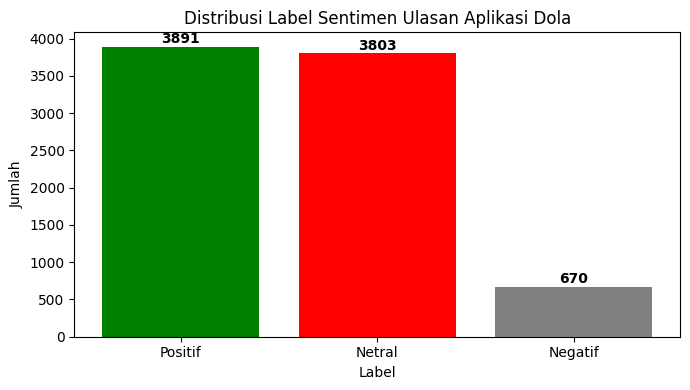

In [3]:
import matplotlib.pyplot as plt

sentimen_count = data_clean['Label'].value_counts()

print("=== DISTRIBUSI LABEL SENTIMEN ===")
print(sentimen_count)
print(f"\nTotal data : {len(data_clean)}")

plt.figure(figsize=(7, 4))
bars = plt.bar(sentimen_count.index, sentimen_count.values, color=['green', 'red', 'gray'])
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.title('Distribusi Label Sentimen Ulasan Aplikasi Dola')
for bar, val in zip(bars, sentimen_count.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Splitting Data 80:20

In [4]:
from sklearn.model_selection import train_test_split

X = data_clean['text_stemindo'].fillna('')
y = data_clean['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== HASIL SPLITTING DATA (80:20) ===")
print(f"Total data          : {len(X)}")
print(f"Jumlah Data Train   : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Jumlah Data Test    : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print()
print("Distribusi label data train:")
print(y_train.value_counts())
print()
print("Distribusi label data test:")
print(y_test.value_counts())
print()

n_features = len(set(' '.join(X_train.tolist()).split()))
ratio = len(X_train) / n_features
print("=== ANALISIS SPLITTING ===")
print(f"Jumlah fitur (vocab size) : {n_features}")
print(f"Rasio data train/fitur    : {ratio:.4f}")
if ratio < 1:
    print("Indikasi : Berisiko UNDERFITTING — data train lebih sedikit dari jumlah fitur.")
    print("Saran    : Tambah data atau kurangi fitur (misal: batasi max_features TF-IDF).")
elif ratio < 5:
    print("Indikasi : Data train cukup namun perlu diperhatikan kompleksitas model.")
else:
    print("Indikasi : Data train cukup representatif, risiko underfitting rendah.")

=== HASIL SPLITTING DATA (80:20) ===
Total data          : 8364
Jumlah Data Train   : 6691 (80%)
Jumlah Data Test    : 1673 (20%)

Distribusi label data train:
Label
Positif    3113
Netral     3042
Negatif     536
Name: count, dtype: int64

Distribusi label data test:
Label
Positif    778
Netral     761
Negatif    134
Name: count, dtype: int64

=== ANALISIS SPLITTING ===
Jumlah fitur (vocab size) : 6307
Rasio data train/fitur    : 1.0609
Indikasi : Data train cukup namun perlu diperhatikan kompleksitas model.


## 4. Pembobotan TF-IDF (80:20)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print("=== HASIL TF-IDF (80:20) ===")
print(f"Ukuran matriks train : {X_train_tfidf.shape}")
print(f"Ukuran matriks test  : {X_test_tfidf.shape}")
print(f"Jumlah fitur vocab   : {len(tfidf_vectorizer.vocabulary_)}")

=== HASIL TF-IDF (80:20) ===
Ukuran matriks train : (6691, 6282)
Ukuran matriks test  : (1673, 6282)
Jumlah fitur vocab   : 6282


## 5. Training SVM (80:20)

In [6]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_tfidf, y_train)
y_pred = svm_model.predict(X_test_tfidf)

print("=== HASIL TRAINING SVM (80:20) ===")
print("Model SVM dengan kernel linear berhasil dilatih.")
print(f"Jumlah data train : {len(X_train)}")
print(f"Jumlah data test  : {len(X_test)}")

=== HASIL TRAINING SVM (80:20) ===
Model SVM dengan kernel linear berhasil dilatih.
Jumlah data train : 6691
Jumlah data test  : 1673


## 6. Classification Report (80:20)

In [7]:
from sklearn.metrics import classification_report, accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("=== HASIL EVALUASI SVM (80:20) ===")
print(f"Akurasi : {accuracy:.4f} ({accuracy*100:.2f}%)")
print()
print("=== CLASSIFICATION REPORT (80:20) ===")
print(classification_report(y_test, y_pred, target_names=['Negatif', 'Netral', 'Positif']))

=== HASIL EVALUASI SVM (80:20) ===
Akurasi : 0.8852 (88.52%)

=== CLASSIFICATION REPORT (80:20) ===
              precision    recall  f1-score   support

     Negatif       0.75      0.60      0.66       134
      Netral       0.86      0.93      0.89       761
     Positif       0.94      0.90      0.92       778

    accuracy                           0.89      1673
   macro avg       0.85      0.81      0.82      1673
weighted avg       0.89      0.89      0.88      1673



## 7. Confusion Matrix (80:20)

=== CONFUSION MATRIX (80:20) ===
[[ 80  41  13]
 [ 24 704  33]
 [  3  78 697]]



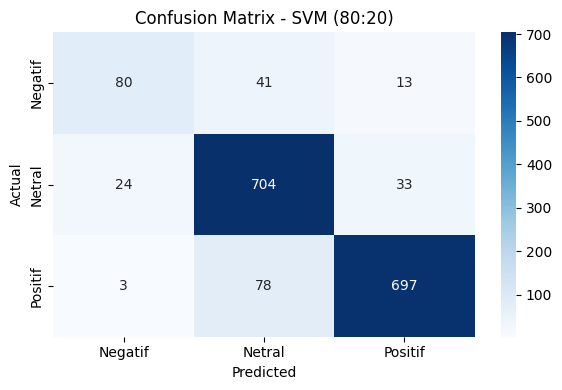

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=['Negatif', 'Netral', 'Positif'])

print("=== CONFUSION MATRIX (80:20) ===")
print(cm)
print()

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - SVM (80:20)')
plt.tight_layout()
plt.show()

## 8. Simpan Model ke Google Drive

In [9]:
import joblib, os

MODEL_PATH = f'{DRIVE_PATH}/model_svm_8020'
os.makedirs(MODEL_PATH, exist_ok=True)

joblib.dump(svm_model, f'{MODEL_PATH}/svm_model.joblib')
joblib.dump(tfidf_vectorizer, f'{MODEL_PATH}/tfidf_vectorizer.joblib')

print(f"Model SVM (80:20) disimpan di: {MODEL_PATH}")

Model SVM (80:20) disimpan di: /content/drive/MyDrive/Skripsi_Faris/model_svm_8020
